In [1]:
import osmnx as ox
import matplotlib.pyplot as plt
import seaborn as sns
import h3
import pandas as pd
import os
from pathlib import Path
import geopandas as gpd
import contextily as ctx
import shapely
import geopandas as gpd
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# POI - Points of Interest
In this unit we download the POI data for the city of chicago, if not already in data folder.
Then we process the resulting table and combine the values for amenities, shops and tourism pois into one column. By combining them we are able to remove all null values in these columns.

Then we use the lattitude and longitude of the POIS to add the H3 Index as a new column which we will later use to combine the taxi data with the POI data.

## 1. POI Data Extraction


In [2]:
# Define project parameters
place_name = "Chicago, Illinois, USA"
tags = {'amenity': True, 'shop': True, 'tourism': True}

project_root = Path(".").resolve().parent
data_dir = project_root / "data"
file_path = data_dir / "chicago_pois_download.gpkg"
data_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# Configure OSMnx for a large, slow Overpass query.
# The default read timeout is 180s and the public overpass-api.de server is
# often too overloaded to answer a city-wide amenity+shop+tourism query in time.
ox.settings.use_cache = True          # reuse a successful download instead of re-querying
ox.settings.overpass_rate_limit = True
ox.settings.requests_timeout = 600    # allow up to 10 min per request (was 180)

# Mirrors to try in order; the public default server is the most overloaded one.
overpass_mirrors = [
    "https://overpass.kumi.systems/api",
    "https://overpass.private.coffee/api",
    "https://overpass-api.de/api",
]

# Check if data is already downloaded
if os.path.exists(file_path):
    print(f"Loading data from local file.")
    pois = gpd.read_file(file_path)
else:
    print(f"Data not found. Downloading {place_name} POIs... (This may take a few minutes)")
    pois = None
    for url in overpass_mirrors:
        try:
            ox.settings.overpass_url = url
            print(f"  trying mirror: {url}")
            pois = ox.features_from_place(place_name, tags)
            print(f"  success via {url}")
            break
        except Exception as e:
            print(f"  failed on {url}: {type(e).__name__}: {e}")
    if pois is None:
        raise RuntimeError("All Overpass mirrors failed — check your connection and try again later.")

    # Save it locally for next time
    # Save as GeoPackage (.gpkg) because it's faster and better for spatial data than CSV
    pois.to_file(file_path, driver="GPKG")
    print(f"Data saved to {file_path}")

print(f"Total POIs loaded: {len(pois)}")
pois.head()

Loading data from local file.


Total POIs loaded: 43237


,element,id,amenity,ferry,name,network,operator,public_transport,source,tourism,...,name:tl,not:name,diet:dairy_free,building:levels:underground,building:roof,roof,nohousenumber,levels,abbr_name,geometry
0,node,20217109,ferry_terminal,yes,Shoreline Sightseeing,Shoreline Water Taxi,Shoreline Water Taxi,station,PGS,attraction,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.62252 41.88914)
1,node,20217442,ferry_terminal,yes,Union Station/Willis Tower,Shoreline Water Taxi,Shoreline Water Taxi,station,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.63774 41.87906)
2,node,269449042,parking_entrance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.61506 41.85869)
3,node,269450074,parking_entrance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.5842 41.79178)
4,node,269450344,parking_entrance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.61195 41.84968)


## 2. Data Augmentation and Pre-Processing

In [4]:
# Investigate missing values in key columns
print("Missing values in 'amenity':", pois['amenity'].isna().sum())
print("Missing values in 'shop':", pois['shop'].isna().sum())
print("Missing values in 'tourism':", pois['tourism'].isna().sum())

# Create a DataFrame of POIs with missing 'amenity' but have 'shop' or 'tourism' tags
missing_amenity_df = pois[pois['amenity'].isna() & (pois['shop'].notna() | pois['tourism'].notna())]
print(f"Number of POIs with missing 'amenity' but have 'shop' or 'tourism': {len(missing_amenity_df)}")

# Analyze the unique values in 'amenity', 'shop', and 'tourism' columns
unique_amenities = pois['amenity'].dropna().unique()
print(f"Total unique amenities: {len(unique_amenities)}")

Missing values in 'amenity': 7053
Missing values in 'shop': 37552
Missing values in 'tourism': 41738
Number of POIs with missing 'amenity' but have 'shop' or 'tourism': 7053
Total unique amenities: 138


In [5]:
# Create a new 'poi_type' column that combines 'amenity', 'shop', and 'tourism' tags
pois["poi_type"] = pois["amenity"]
pois["poi_type"] = pois["poi_type"].fillna(pois["shop"]).fillna(pois["tourism"])

# Check how many POIs still have missing 'poi_type' after combining the tags
print(f"Total POIs with missing 'poi_type': {pois['poi_type'].isna().sum()}")

unique_poi_types = pois['poi_type'].unique()
print(f"Total unique poi types: {len(unique_poi_types)}")
print(list(unique_poi_types))

Total POIs with missing 'poi_type': 0
Total unique poi types: 311
['ferry_terminal', 'parking_entrance', 'post_box', 'bicycle', 'loading_dock', 'theatre', 'convenience', 'bicycle_parking', 'fast_food', 'books', 'post_office', 'drinking_water', 'restaurant', 'pharmacy', 'stationery', 'fuel', 'cinema', 'cafe', 'clock', 'pub', 'vacant', 'school', 'university', 'kindergarten', 'place_of_worship', 'dojo', 'driving_school', 'childcare', 'college', 'music_school', 'artwork', 'language_school', 'prep_school', 'public_bath', 'social_centre', 'art', 'social_facility', 'arts_centre', 'courthouse', 'library', 'information', 'bar', 'clothes', 'bank', 'supermarket', 'atm', 'parking', 'hotel', 'ice_cream', 'car_wash', 'veterinary', 'dry_cleaning', 'beauty', 'costume', 'doctors', 'electronics', 'alcohol', 'houseware', 'furniture', 'military_surplus', 'bakery', 'fountain', 'dentist', 'general', 'pastry', 'hobby', 'community_centre', 'toilets', 'newsagent', 'cannabis', 'gift', 'hairdresser', 'department

### H3 Hexagon Augmentation

In [6]:
# Method to match with H3 Hexagons Index
# We'll use resolution 8 as a starting point for "discretizing the city"
def get_h3_index(row, resolution):
    centroid = row.geometry.centroid
    return h3.latlng_to_cell(centroid.y, centroid.x, resolution)

pois['h3_index_7'] = pois.apply(lambda row: get_h3_index(row, resolution=7), axis=1)
pois['h3_index_8'] = pois.apply(lambda row: get_h3_index(row, resolution=8), axis=1)
pois.head()

,element,id,amenity,ferry,name,network,operator,public_transport,source,tourism,...,building:levels:underground,building:roof,roof,nohousenumber,levels,abbr_name,geometry,poi_type,h3_index_7,h3_index_8
0,node,20217109,ferry_terminal,yes,Shoreline Sightseeing,Shoreline Water Taxi,Shoreline Water Taxi,station,PGS,attraction,...,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.62252 41.88914),ferry_terminal,872664c1effffff,882664c1e3fffff
1,node,20217442,ferry_terminal,yes,Union Station/Willis Tower,Shoreline Water Taxi,Shoreline Water Taxi,station,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.63774 41.87906),ferry_terminal,872664c1affffff,882664c1adfffff
2,node,269449042,parking_entrance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.61506 41.85869),parking_entrance,872664c1bffffff,882664c1b1fffff
3,node,269450074,parking_entrance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.5842 41.79178),parking_entrance,872664cc5ffffff,882664cc59fffff
4,node,269450344,parking_entrance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.61195 41.84968),parking_entrance,872664c1bffffff,882664c1b3fffff


In [7]:
# Census tract + community area for each POI, taken from the SAME boundary file the taxi grid in
# 1.4 uses, so the POI features and the demand grid are defined on identical spatial units.
census_comm = gpd.read_file(Path('..') / 'data' / 'chicago_census_comm.gpkg').to_crs(epsg=4326)

# Match on the POI centroid, exactly as the h3 assignment above does -- roughly half the POIs are
# building polygons rather than points, and both levels must be derived from the same location.
poi_points = gpd.GeoDataFrame(geometry=pois.geometry.centroid, crs=pois.crs)

matched = gpd.sjoin(
    poi_points,
    census_comm[['geoid10', 'commarea', 'geometry']],
    how='left',
    predicate='within',
)
# A centroid landing exactly on a shared border can match two polygons; keep the first.
matched = matched[~matched.index.duplicated()]

pois['geoid10'] = matched['geoid10']
pois['commarea'] = matched['commarea']

outside = int(pois['geoid10'].isna().sum())
print(f"{len(pois) - outside:,} of {len(pois):,} POIs matched a census tract; "
      f"{outside} fall outside the city boundary (OSM returns a slightly larger bounding area than "
      f"the official limits) and are excluded from the tract/community aggregations.")
print(f"coverage: {pois['geoid10'].nunique()} of {census_comm['geoid10'].nunique()} census tracts | "
      f"{pois['commarea'].nunique()} of {census_comm['commarea'].nunique()} community areas")

43,156 of 43,237 POIs matched a census tract; 81 fall outside the city boundary (OSM returns a slightly larger bounding area than the official limits) and are excluded from the tract/community aggregations.
coverage: 798 of 801 census tracts | 77 of 77 community areas


/var/folders/mb/d7qxmv150dz1wszhty3l250c0000gn/T/ipykernel_82818/1927791366.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  poi_points = gpd.GeoDataFrame(geometry=pois.geometry.centroid, crs=pois.crs)


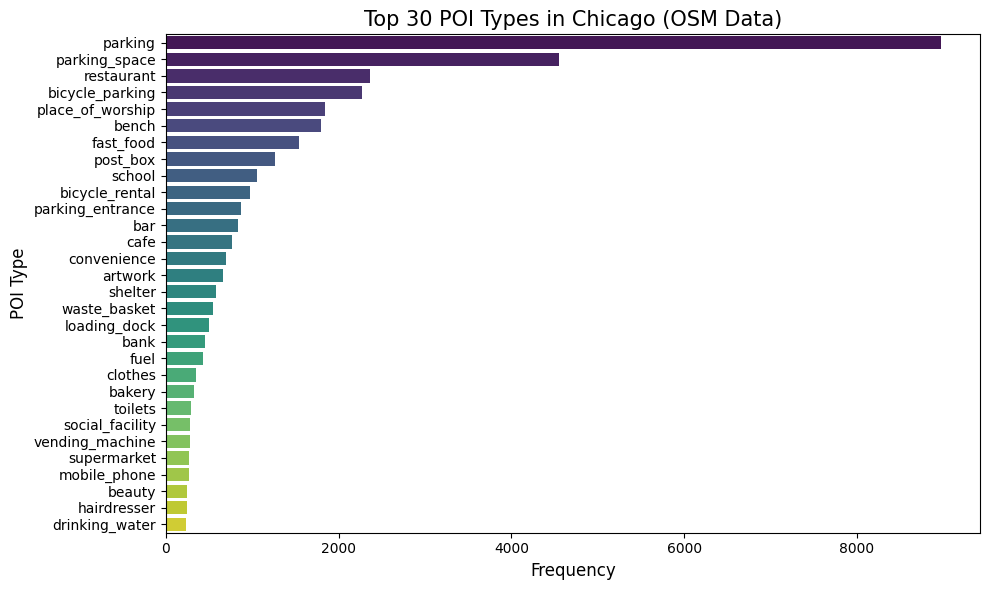

In [8]:
# Top 30 most common POI types
poi_counts = pois['poi_type'].value_counts().head(30)
# Create Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=poi_counts.values, y=poi_counts.index, palette='viridis', hue = poi_counts.index, legend=False)
plt.title('Top 30 POI Types in Chicago (OSM Data)', fontsize=15)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('POI Type', fontsize=12)
plt.tight_layout()
plt.show()

## 3. POIs Categorisation

In [9]:
# Reset index to turn 'osmid' into a column
pois = pois.reset_index()
pois = pois.rename(columns={'osmid': 'id'})

# Keep only relevant columns and drop rows with missing geometry.
# geoid10 / commarea ride along so the tract and community-area aggregations can be built after the
# geometry is dropped.
pois = pois[['id', 'h3_index_7', 'h3_index_8', 'geoid10', 'commarea',
             'poi_type', 'name', 'geometry']].dropna(subset=["geometry"])
pois = pois.drop(columns=['geometry'])
print(f"POI entries retained before categorisation: {len(pois)}")

POI entries retained before categorisation: 43237


### Aggregate POI types into broad categories (and filter)
We impose a **logical categorisation**: The raw OSM tags give us ~300 highly granular `poi_type` values, which are too sparse to be useful as model features. We apply a manual decision rule that maps each `poi_type` into a small set of demand-relevant categories (`food_drink`, `nightlife`, `entertainment`, `leisure_sports`, `grocery`, `shopping`, `health`, `finance`, `education`, `lodging`, `transport`, `automotive`, `services`, `civic_community`). The result is stored in a new `poi_category` column.

This rule **also acts as the filter**: any `poi_type` that does not map to a category becomes `other` and is dropped. The dropped set is almost entirely infrastructure / hyper-local objects (benches, parking, post boxes, toilets, waste bins, charging stations, ...) that probably don't drive ride-hailing demand. The list of dropped types is printed so the rule stays auditable and easy to refine.

In [ ]:
# Aggregate the ~300 granular poi_types into a handful of broad, demand-relevant categories.
# The mapping below is the decision rule: each broad category lists the raw poi_type values that belong to it. 
# Any poi_type not listed falls back to 'other' and is dropped at the end of this cell.

poi_category_rules = {
    'food_drink': [
        'restaurant', 'fast_food', 'cafe', 'ice_cream', 'food_court', 'deli',
        'snack', 'coffee', 'confectionery', 'chocolate', 'pastry', 'street_vendor',
        'food_sharing',
    ],
    'nightlife': [
        'bar', 'pub', 'nightclub', 'biergarten', 'stripclub', 'casino',
        'bookmaker', 'erotic',
    ],
    'entertainment': [
        'theatre', 'cinema', 'arts_centre', 'artwork', 'gallery', 'museum',
        'studio', 'planetarium', 'aquarium', 'zoo', 'theme_park', 'attraction',
        'viewpoint', 'exhibition_centre', 'conference_centre', 'events_venue',
    ],
    'leisure_sports': [
        'sports', 'fishing', 'scuba_diving', 'boat_rental', 'picnic_site',
        'outdoor', 'hobby', 'games', 'video_games', 'dojo',
    ],
    'grocery': [
        'supermarket', 'convenience', 'grocery', 'bakery', 'bakery;pastry',
        'butcher', 'greengrocer', 'seafood', 'cheese', 'spices', 'nuts',
        'dry_food', 'health_food', 'beverages', 'wine', 'alcohol', 'tea',
        'farm', 'marketplace', 'kiosk',
    ],
    'shopping': [
        'clothes', 'shoes', 'jewelry', 'bag', 'fashion_accessories', 'costume',
        'leather', 'wigs', 'haberdashery', 'tailor', 'sewing', 'fabric', 'wool',
        'household_linen', 'department_store', 'mall', 'variety_store', 'general',
        'clothes;stationary', 'wholesale', 'trade', 'freeshop', 'second_hand',
        'charity', 'antiques', 'collector', 'gift', 'gift shop', 'party', 'books',
        'newsagent', 'stationery', 'educational_supply', 'art', 'frame', 'craft',
        'musical_instrument', 'music', 'video', 'camera', 'photo', 'hifi',
        'electronics', 'computer', 'mobile_phone', 'telecommunication',
        'e-cigarette', 'tobacco', 'cannabis', 'electrical', 'lighting',
        'furniture', 'furniture;appliance', 'appliance', 'interior_decoration',
        'houseware', 'kitchen', 'carpet', 'flooring', 'tiles', 'paint', 'doors',
        'window_blind', 'curtain', 'bed', 'garden_centre', 'florist',
        'doityourself', 'hardware', 'agrarian', 'brewing_supplies',
        'hairdresser_supply', 'perfumery', 'chemist', 'toys',
        'baby_goods', 'pet', 'watches', 'candles', 'esoteric', 'herbalist',
        'nutrition_supplements', 'boat', 'motorcycle', 'bicycle', 'power_tools',
        'printer_ink', 'military_surplus',
    ],
    'health': [
        'pharmacy', 'doctors', 'dentist', 'clinic', 'hospital', 'optician',
        'hearing_aids', 'medical_supply', 'veterinary', 'nursing_home',
        'retirement_home',
    ],
    'finance': [
        'bank', 'atm', 'bureau_de_change', 'money_lender', 'money_transfer',
        'payment_centre', 'financial', 'pawnbroker',
    ],
    'education': [
        'school', 'university', 'college', 'kindergarten', 'childcare',
        'library', 'music_school', 'driving_school', 'dancing_school',
        'flight_school', 'research_institute', 'training', 'prep_school',
        'language_school', 'public_bath',
    ],
    'lodging': [
        'hotel', 'motel', 'hostel', 'guest_house', 'chalet', 'apartment',
    ],
    'transport': [
        'ferry_terminal', 'bus_station', 'taxi', 'car_rental', 'car_sharing',
        'bicycle_rental', 'charging_station', 'fuel', 'valet_parking',
    ],
    'automotive': [
        'car', 'car_repair', 'car_parts', 'car_wash', 'tyres',
        'vehicle_inspection', 'car_pound',
    ],
    'services': [
        'hairdresser', 'beauty', 'massage', 'spa', 'wellness', 'tattoo',
        'cosmetics', 'laundry', 'dry_cleaning', 'laundry;dry_cleaning',
        'copyshop', 'travel_agency', 'estate_agent', 'funeral_directors',
        'locksmith', 'glaziery', 'cabinet_maker', 'shoe_repair', 'repair',
        'rental', 'storage_rental', 'internet_cafe', 'psychic', 'pet_grooming',
        'post_office', 'post_depot', 'ticket', 'telephone', 'animal_boarding',
        'animal_training', 'mortuary', 'tool_library', 'lost_property_office',
    ],
    'civic_community': [
        'place_of_worship', 'religion', 'community_centre', 'social_centre',
        'social_facility', 'courthouse', 'police', 'fire_station', 'townhall',
        'ranger_station', 'information', 'monastery', 'grave_yard', 'crematorium',
        'prison',
    ],
}
# NOTE: 'cosmetics' previously appeared in both 'shopping' and 'services' above. The lookup below
# is built by iterating categories in dict order, so the later definition ('services') silently won
# regardless -- removed the dead 'shopping' entry so that outcome is explicit rather than accidental.
# No downstream numbers change: 'cosmetics' was already being counted under 'services'.

# Invert the rules into a flat {poi_type: category} lookup.
poi_type_to_category = {
    poi_type: category
    for category, poi_types in poi_category_rules.items()
    for poi_type in poi_types
}

# Apply the decision rule; anything unmapped becomes 'other'.
pois['poi_category'] = pois['poi_type'].map(poi_type_to_category).fillna('other')

print("POIs per broad category (before dropping 'other'):")
print(pois['poi_category'].value_counts())

# The poi_types that do not fit any category — these are what gets dropped.
unmapped = sorted(pois.loc[pois['poi_category'] == 'other', 'poi_type'].unique())
print(f"\n{len(unmapped)} poi_type(s) fall into 'other' and will be dropped:")
print(list(unmapped))

# Filter: keep only POIs that map to a real category.
before = len(pois)
pois = pois[pois['poi_category'] != 'other'].copy()
print(f"\nDropped {before - len(pois)} POIs that did not fit any category; {len(pois)} remain.")

In [11]:
# Export POIS table to use in other notebooks
pois.to_csv(data_dir / "processed/chicago_pois_cleaned.csv", index=False)

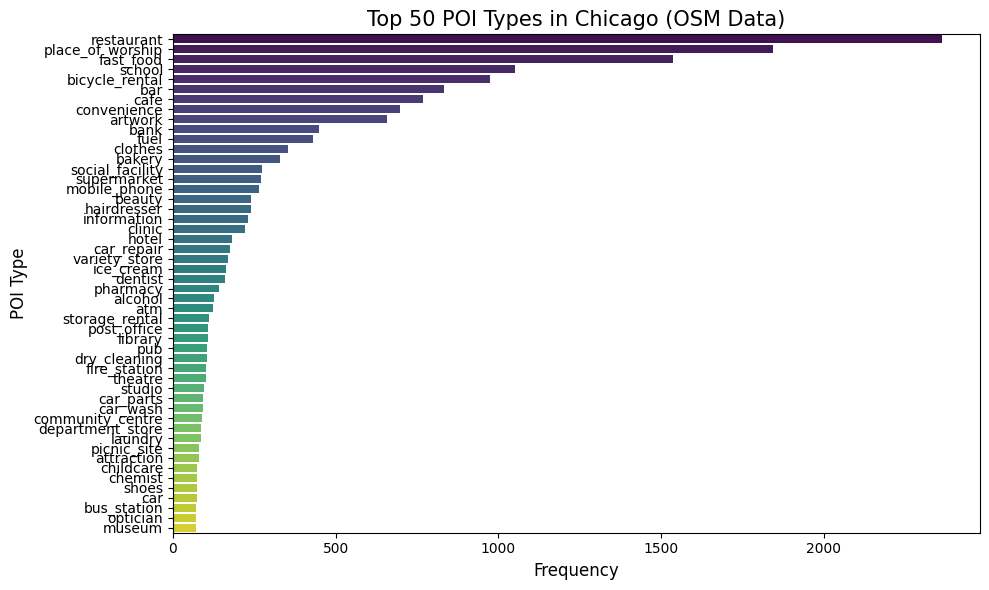

In [12]:
poi_counts = pois['poi_type'].value_counts().head(50) # Top 50 for clarity
# Create Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=poi_counts.values, y=poi_counts.index, palette='viridis', hue = poi_counts.index, legend=False)
plt.title('Top 50 POI Types in Chicago (OSM Data)', fontsize=15)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('POI Type', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Aggregation

In [13]:
# Define the aggregation rules for unit-level summarization.
poi_aggregations = {
    'poi_count': ('id', 'count'),
    'count_poi_types': ('poi_type', lambda x: x.nunique()),  # Count of unique POI types per unit
    'poi_type_list': ('poi_type', lambda x: ', '.join(x)),   # List of POI types per unit
    'poi_list': ('name', lambda x: ', '.join(x.dropna())),   # List of POI names per unit
}

# The four spatial levels the taxi grid is built on. 'col' is the column in `pois` holding the unit
# id; 'key' is the column name written to the CSV. The h3 files keep the generic 'h3_index' key that
# the existing feature-engineering notebooks merge on; the tract and community files use the same
# names as the demand grids (geoid10 / commarea).
poi_levels = {
    'h3_7':      {'col': 'h3_index_7', 'key': 'h3_index', 'suffix': '7'},
    'h3_8':      {'col': 'h3_index_8', 'key': 'h3_index', 'suffix': '8'},
    'census':    {'col': 'geoid10',    'key': 'geoid10',  'suffix': 'census'},
    'community': {'col': 'commarea',   'key': 'commarea', 'suffix': 'community'},
}

# Pin the category columns so every level produces the SAME feature matrix, even if a coarse level
# happens to contain a category that a fine one does not (or vice versa).
ALL_CATEGORIES = sorted(poi_category_rules)
print(f'{len(ALL_CATEGORIES)} POI categories: {ALL_CATEGORIES}')

14 POI categories: ['automotive', 'civic_community', 'education', 'entertainment', 'finance', 'food_drink', 'grocery', 'health', 'leisure_sports', 'lodging', 'nightlife', 'services', 'shopping', 'transport']


In [14]:
# Build both aggregations at every spatial level:
#   pois_agg[level]      -- one row per unit, overall POI counts
#   pois_cat_wide[level] -- one row per unit, one count column per category (the feature matrix)
pois_agg = {}
pois_cat_wide = {}

for level, spec in poi_levels.items():
    col, key, suffix = spec['col'], spec['key'], spec['suffix']

    # groupby drops NaN keys, so POIs outside the city boundary simply do not appear at the
    # tract/community levels.
    agg = (
        pois.groupby(col)
            .agg(**poi_aggregations)
            .reset_index()
            .rename(columns={col: key})
    )

    wide = (
        pois.groupby([col, 'poi_category'])
            .agg(**poi_aggregations)
            .reset_index()
            .pivot(index=col, columns='poi_category', values='poi_count')
            .reindex(columns=ALL_CATEGORIES)   # a unit may be missing a category entirely
            .fillna(0)
            .astype(int)
            .add_prefix('poi_cat_')
            .rename_axis(key)
            .reset_index()
    )
    wide.columns.name = None

    pois_agg[level] = agg
    pois_cat_wide[level] = wide

    agg.to_csv(data_dir / f'processed/chicago_pois_agg_{suffix}.csv', index=False)
    wide.to_csv(data_dir / f'processed/chicago_pois_category_wide_{suffix}.csv', index=False)

    print(f'{level:10s} {len(agg):>4} units  {agg["poi_count"].sum():>6,} POIs  '
          f'-> chicago_pois_agg_{suffix}.csv, chicago_pois_category_wide_{suffix}.csv')

# The visualisation cells below still refer to the h3 frames by name.
pois_agg_7, pois_agg_8 = pois_agg['h3_7'], pois_agg['h3_8']
pois_cat_wide_7, pois_cat_wide_8 = pois_cat_wide['h3_7'], pois_cat_wide['h3_8']

pois_cat_wide['community'].head()

h3_7        152 units  20,108 POIs  -> chicago_pois_agg_7.csv, chicago_pois_category_wide_7.csv


h3_8        806 units  20,108 POIs  -> chicago_pois_agg_8.csv, chicago_pois_category_wide_8.csv


census      797 units  20,084 POIs  -> chicago_pois_agg_census.csv, chicago_pois_category_wide_census.csv
community    77 units  20,084 POIs  -> chicago_pois_agg_community.csv, chicago_pois_category_wide_community.csv


,commarea,poi_cat_automotive,poi_cat_civic_community,poi_cat_education,poi_cat_entertainment,poi_cat_finance,poi_cat_food_drink,poi_cat_grocery,poi_cat_health,poi_cat_leisure_sports,poi_cat_lodging,poi_cat_nightlife,poi_cat_services,poi_cat_shopping,poi_cat_transport
0,1,3,35,18,49,13,83,30,6,0,3,16,24,41,25
1,10,7,30,19,1,13,32,14,11,3,3,9,15,13,10
2,11,9,18,7,7,14,31,17,21,1,0,9,24,16,12
3,12,3,23,9,3,5,21,9,6,0,1,2,17,12,10
4,13,9,22,18,6,1,41,7,6,3,3,2,9,14,15


# Visualizations

In [15]:
def get_hexagon_grid(h3_indices):
    """
    Convert an iterable of H3 cell IDs into a GeoDataFrame of hexagon polygons.
    """
    def _to_polygon(cell):
        # h3-py v4: cell_to_boundary returns [(lat, lng), ...]
        boundary = h3.cell_to_boundary(cell)
        return shapely.geometry.Polygon([(lng, lat) for lat, lng in boundary])

    h3_list = list(h3_indices)
    geometries = [_to_polygon(cell) for cell in h3_list]
    return gpd.GeoDataFrame({'h3_index': h3_list, 'geometry': geometries}, crs='EPSG:4326')

def create_choropleth_plot(gdf,value_col,title,cmap='YlOrRd',figsize=(7, 11),k=7,):
    """
    Create a static matplotlib choropleth of hexagon values with Chicago basemap.
    """
    fig, ax = plt.subplots(figsize=figsize)

    gdf_web = gdf.to_crs(epsg=3857)
    gdf_web.plot(
        ax=ax,
        column=value_col,
        cmap=cmap,
        scheme='quantiles',
        k=k,
        edgecolor='none',
        alpha=0.8,
        legend=True,
        legend_kwds=dict(
            title=value_col.replace('_', ' ').title(),
            loc='lower right',
            fontsize=8,
            title_fontsize=9,
        ),
        missing_kwds=dict(color='lightgrey', label='No data'),
    )

    # Chicago community area outlines as spatial reference
    ca_path = Path('..') / 'data' / 'chicago_community_areas.gpkg'
    if ca_path.exists():
        ca = gpd.read_file(ca_path).to_crs(epsg=3857)
        ca.boundary.plot(ax=ax, color='#333', linewidth=0.8, alpha=0.6)

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=11)
    ax.set_axis_off()
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    return fig, ax

# Visualization 1
Faceted choropleth for overall POI count by hexagon

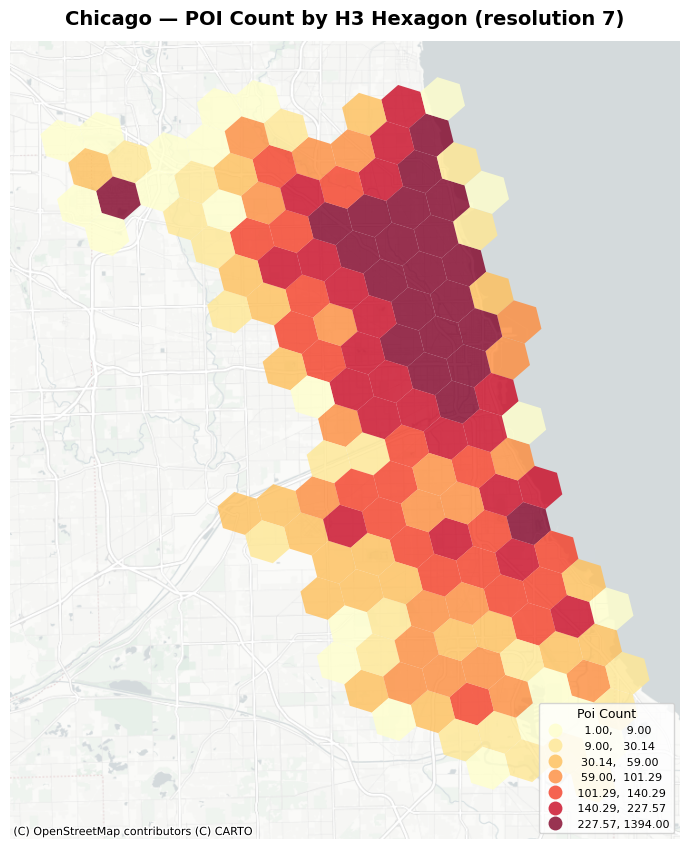

In [16]:
# Build hexagon geometries from the h3_index values already in pois_agg
hex_gdf = get_hexagon_grid(pois_agg_7['h3_index'])
hex_gdf = hex_gdf.merge(pois_agg_7, on='h3_index', how='left')

fig, ax = create_choropleth_plot(
    hex_gdf,
    value_col='poi_count',
    title='Chicago — POI Count by H3 Hexagon (resolution 7)',
)
plt.show()

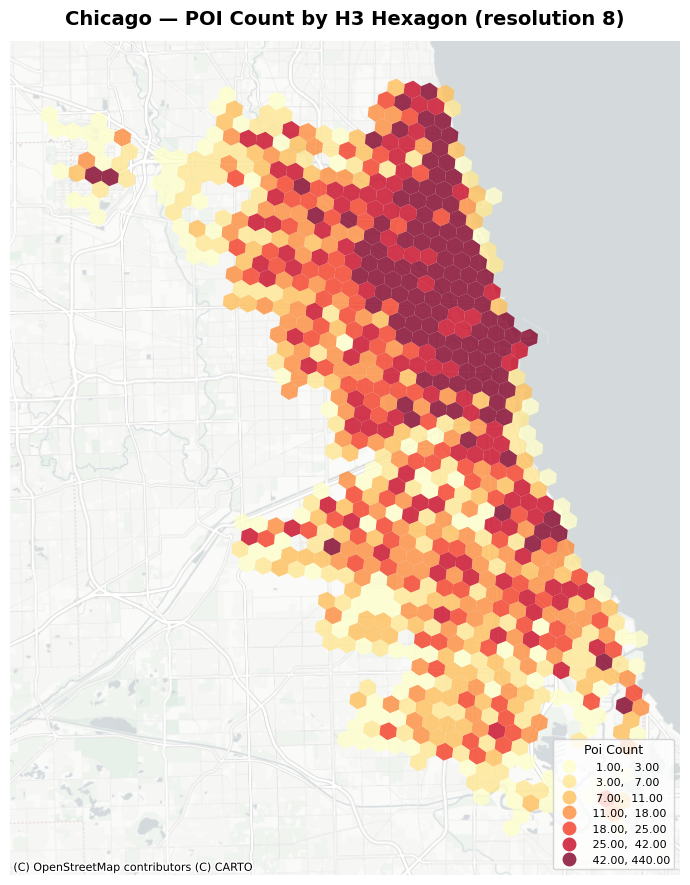

In [17]:
# Build hexagon geometries from the h3_index values already in pois_agg
hex_gdf = get_hexagon_grid(pois_agg_8['h3_index'])
hex_gdf = hex_gdf.merge(pois_agg_8, on='h3_index', how='left')

fig, ax = create_choropleth_plot(
    hex_gdf,
    value_col='poi_count',
    title='Chicago — POI Count by H3 Hexagon (resolution 8)',
)
plt.show()

# Visualization 2
Faceted choropleth: one subplot per POI category so the spatial pattern of each category is visible. 

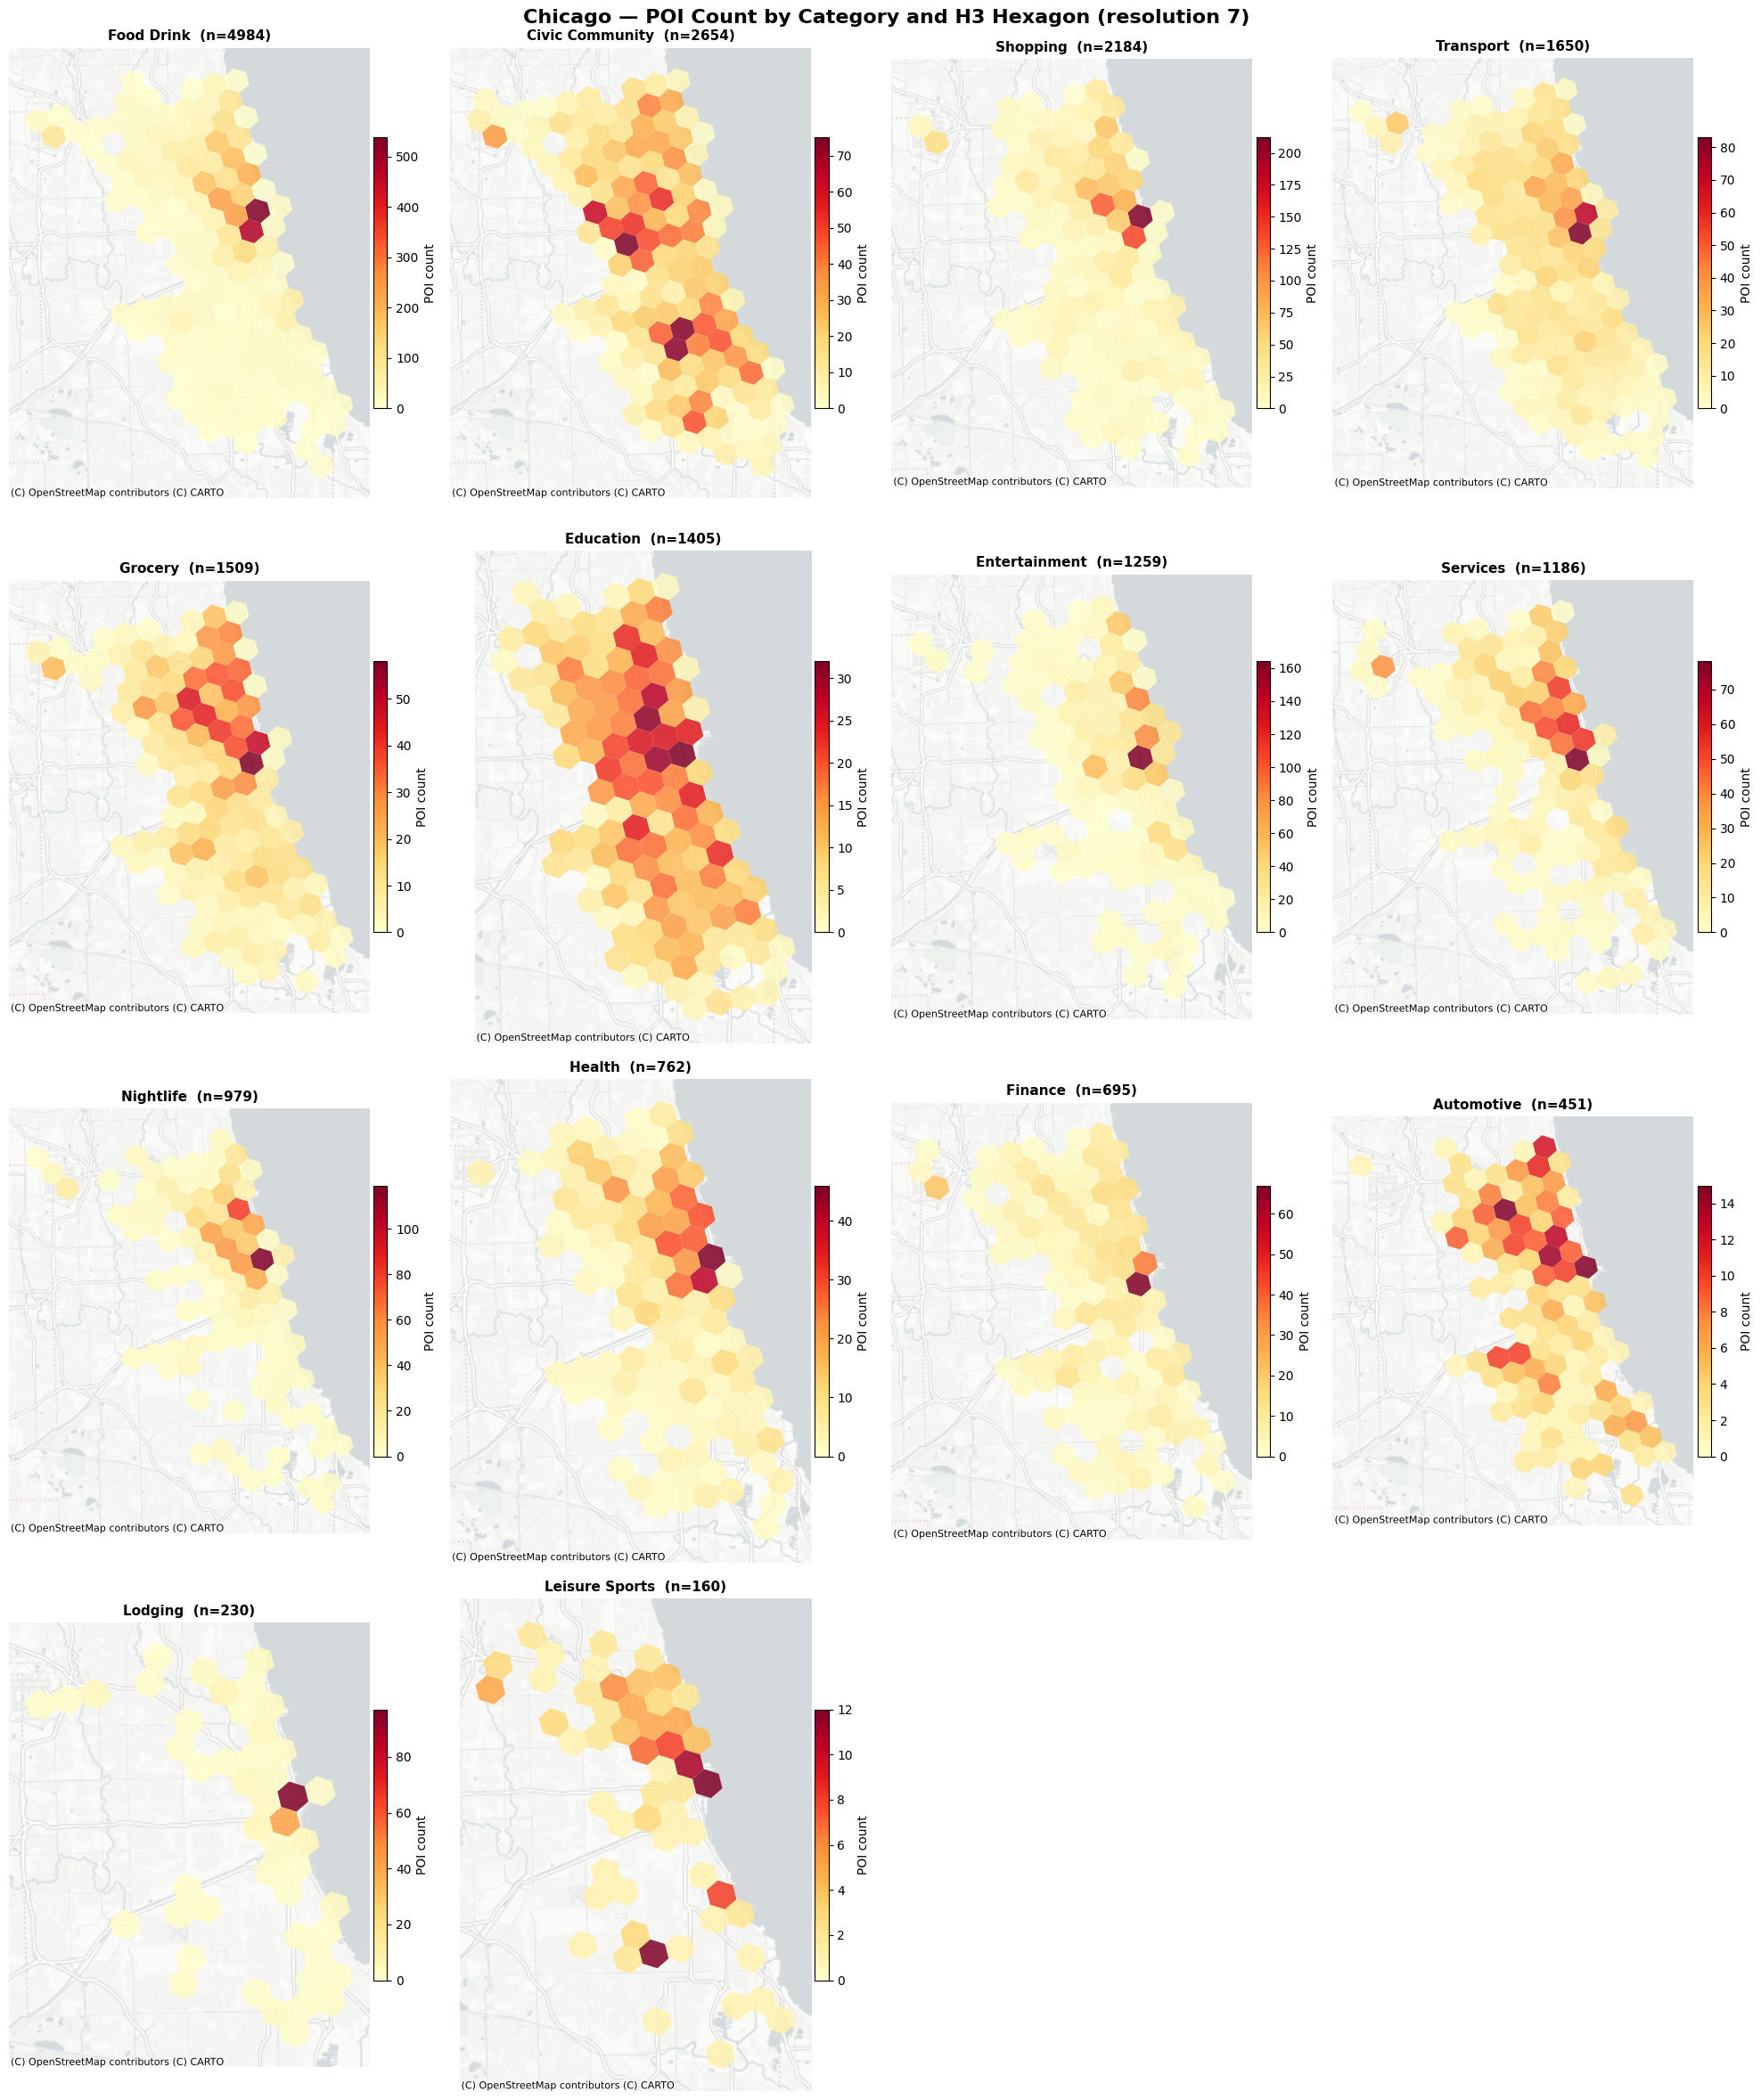

In [18]:
# Build hexagon geometries once, attach the per-category counts, project to web mercator
hex_cat = get_hexagon_grid(pois_cat_wide_7['h3_index']).merge(pois_cat_wide_7, on='h3_index', how='left')
hex_cat = hex_cat.to_crs(epsg=3857)

# Category count columns (busiest category first)
cat_cols = [c for c in hex_cat.columns if c.startswith('poi_cat_')]
cat_cols = sorted(cat_cols, key=lambda c: hex_cat[c].sum(), reverse=True)

# Optional Chicago community-area outlines for spatial reference
ca_path = Path('..') / 'data' / 'chicago_community_areas.gpkg'
ca = gpd.read_file(ca_path).to_crs(epsg=3857) if ca_path.exists() else None

ncols = 4
nrows = int(np.ceil(len(cat_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 6 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, cat_cols):
    if ca is not None:
        ca.boundary.plot(ax=ax, color='#333', linewidth=0.4, alpha=0.5)
    # Only colour hexagons that have at least one POI of this category, with a
    # per-category colour scale (0 .. this category's max) and its own colourbar.
    present = hex_cat[hex_cat[col] > 0]
    if len(present):
        present.plot(
            ax=ax, column=col, cmap='YlOrRd', edgecolor='none', alpha=0.85,
            vmin=0, vmax=int(hex_cat[col].max()),
            legend=True,
            legend_kwds=dict(shrink=0.55, fraction=0.046, pad=0.01, label='POI count'),
        )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=10)
    ax.set_axis_off()
    label = col.replace('poi_cat_', '').replace('_', ' ').title()
    ax.set_title(f"{label}  (n={int(hex_cat[col].sum())})", fontsize=11, fontweight='bold')

# Hide any unused axes in the grid
for ax in axes[len(cat_cols):]:
    ax.set_axis_off()

fig.suptitle('Chicago — POI Count by Category and H3 Hexagon (resolution 7)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

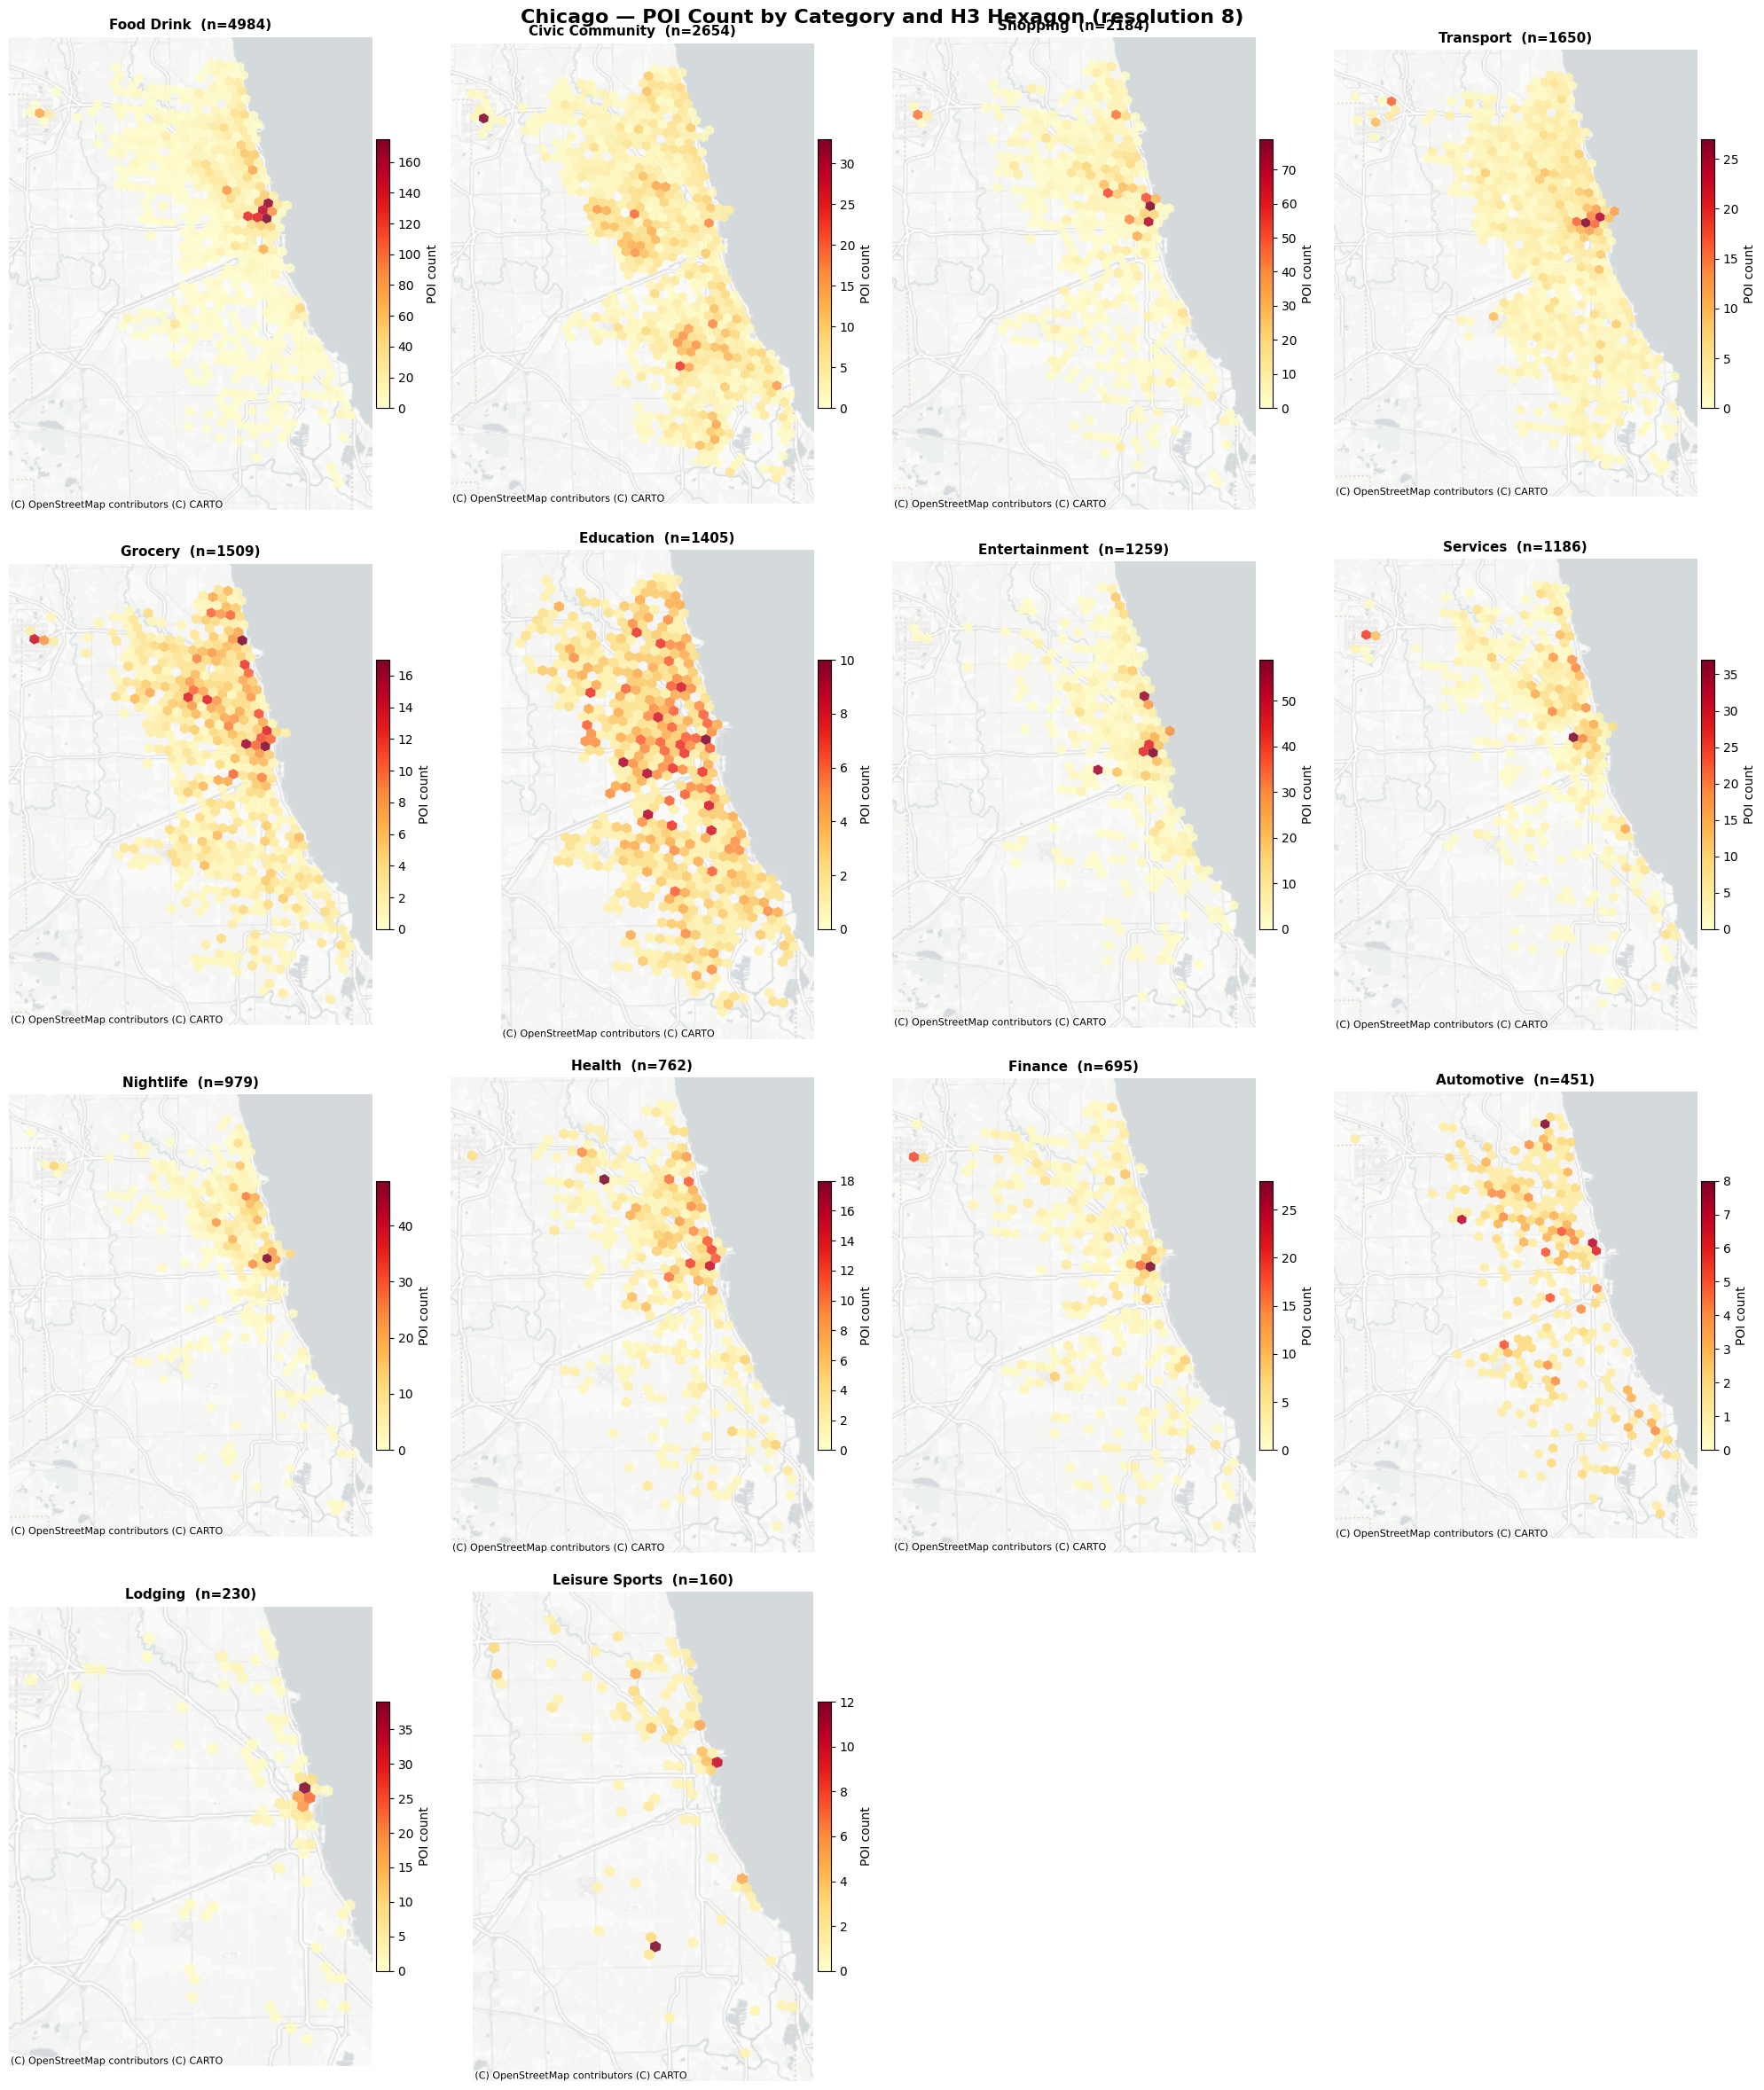

In [19]:
# Build hexagon geometries once, attach the per-category counts, project to web mercator
hex_cat = get_hexagon_grid(pois_cat_wide_8['h3_index']).merge(pois_cat_wide_8, on='h3_index', how='left')
hex_cat = hex_cat.to_crs(epsg=3857)

# Category count columns (busiest category first)
cat_cols = [c for c in hex_cat.columns if c.startswith('poi_cat_')]
cat_cols = sorted(cat_cols, key=lambda c: hex_cat[c].sum(), reverse=True)

# Optional Chicago community-area outlines for spatial reference
ca_path = Path('..') / 'data' / 'chicago_community_areas.gpkg'
ca = gpd.read_file(ca_path).to_crs(epsg=3857) if ca_path.exists() else None

ncols = 4
nrows = int(np.ceil(len(cat_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 6 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, cat_cols):
    if ca is not None:
        ca.boundary.plot(ax=ax, color='#333', linewidth=0.4, alpha=0.5)
    # Only colour hexagons that have at least one POI of this category, with a
    # per-category colour scale (0 .. this category's max) and its own colourbar.
    present = hex_cat[hex_cat[col] > 0]
    if len(present):
        present.plot(
            ax=ax, column=col, cmap='YlOrRd', edgecolor='none', alpha=0.85,
            vmin=0, vmax=int(hex_cat[col].max()),
            legend=True,
            legend_kwds=dict(shrink=0.55, fraction=0.046, pad=0.01, label='POI count'),
        )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=10)
    ax.set_axis_off()
    label = col.replace('poi_cat_', '').replace('_', ' ').title()
    ax.set_title(f"{label}  (n={int(hex_cat[col].sum())})", fontsize=11, fontweight='bold')

# Hide any unused axes in the grid
for ax in axes[len(cat_cols):]:
    ax.set_axis_off()

fig.suptitle('Chicago — POI Count by Category and H3 Hexagon (resolution 8)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualization 3
Correlation between POI categories across H3 hexagons.

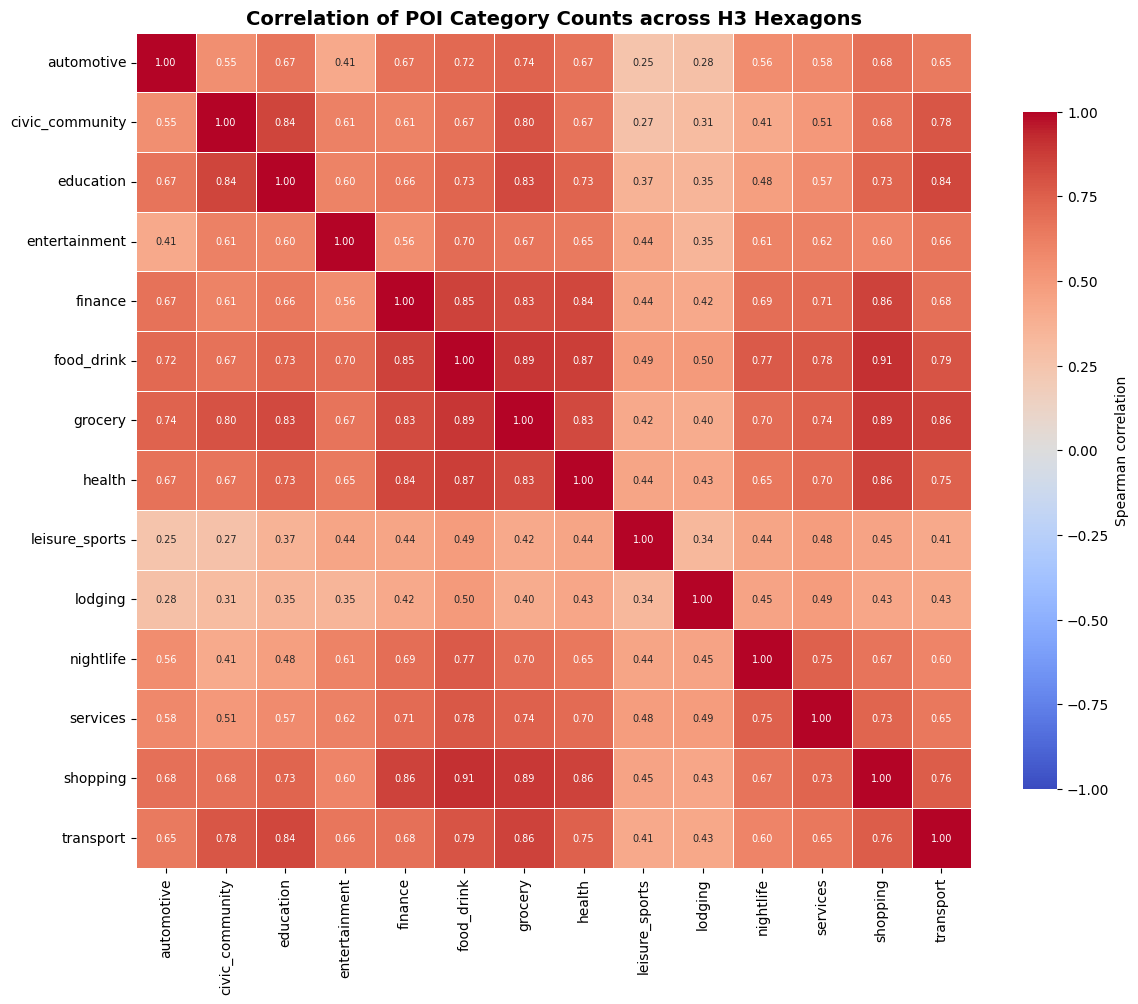

In [20]:
# correlate the categories to see which categories tend to co-occur in the same areas.
heatmap_data = pois_cat_wide_7.set_index('h3_index')
heatmap_data.columns = [c.replace('poi_cat_', '') for c in heatmap_data.columns]

# Spearman is more robust here because per-hexagon counts are sparse and skewed.
corr = heatmap_data.corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1, center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Spearman correlation', 'shrink': 0.8},
    annot_kws={'size': 7},
)
plt.title('Correlation of POI Category Counts across H3 Hexagons', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

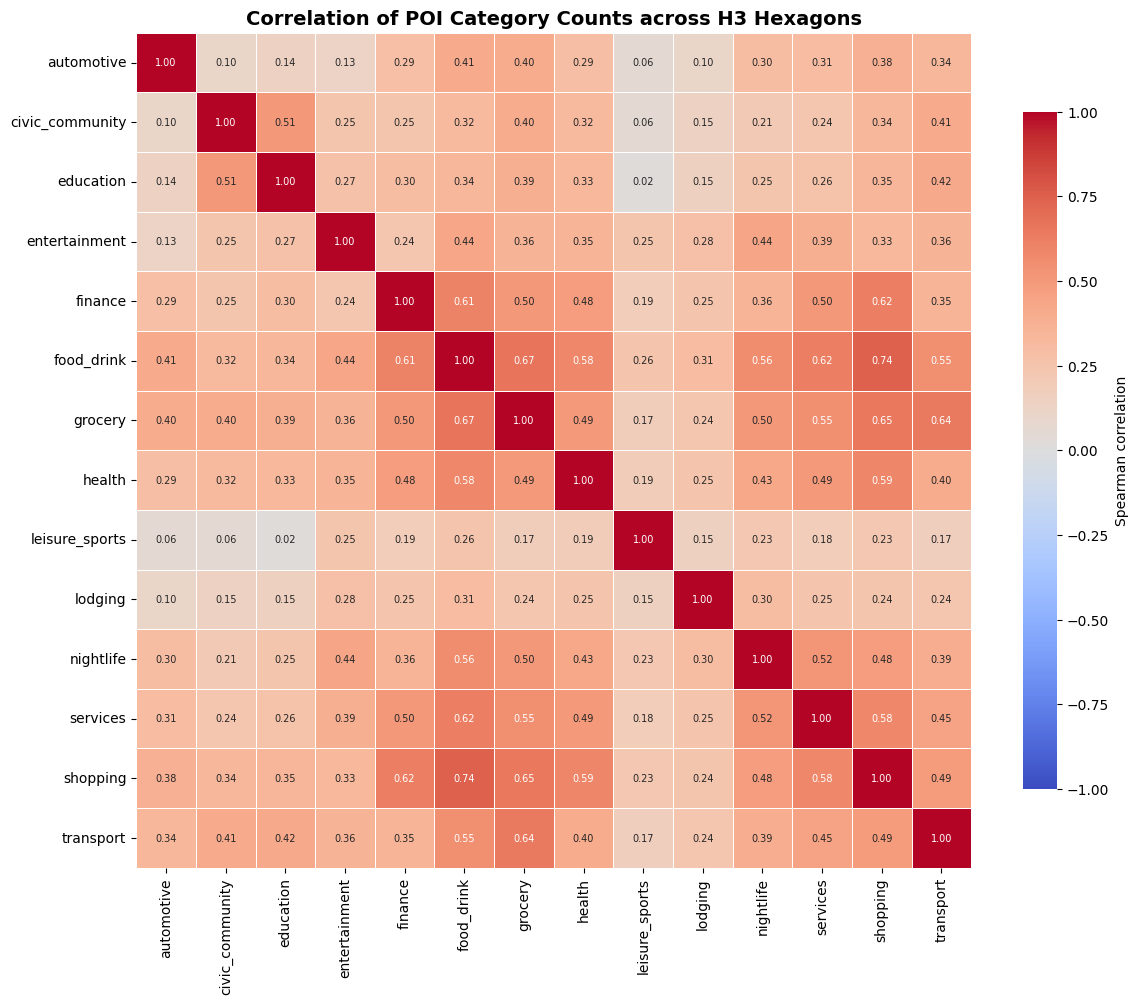

In [21]:
# correlate the categories to see which categories tend to co-occur in the same areas.
heatmap_data = pois_cat_wide_8.set_index('h3_index')
heatmap_data.columns = [c.replace('poi_cat_', '') for c in heatmap_data.columns]

# Spearman is more robust here because per-hexagon counts are sparse and skewed.
corr = heatmap_data.corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1, center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Spearman correlation', 'shrink': 0.8},
    annot_kws={'size': 7},
)
plt.title('Correlation of POI Category Counts across H3 Hexagons', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()